In [1]:
# ═══════════════════════════════════════════════════════════════
# STAGE 1B — IMPROVED: Real Data Integration
# Dengue: 1,523 real patients
# Malaria: 2,190 real patients
# Scrub Typhus, Leptospirosis, Typhoid: synthetic from literature
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
import shap, joblib, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── FEATURE SET we use across all diseases ────────────────────
FEAT = ['age','hemoglobin','wbc','platelets','neutrophils',
        'lymphocytes','rash','eschar','fever_days']

# ══════════════════════════════════════════════════════════════
# PART 1 — LOAD AND CLEAN REAL DATASETS
# ══════════════════════════════════════════════════════════════

# ── DENGUE — 1,523 real patients ──────────────────────────────
df_d = pd.read_csv('/home/mrgreen/scrub_project/data/clinical_raw/'
                   'Dengue Fever Hematological Dataset.csv')

# Keep only positive dengue cases
df_d = df_d[df_d['Result'].str.lower() == 'positive'].copy()

dengue_real = pd.DataFrame({
    'age':         df_d['Age'],
    'hemoglobin':  df_d['Hemoglobin(g/dl)'],
    'wbc':         df_d['Total WBC count(/cumm)'] / 1000,  # convert to 10^3
    'platelets':   df_d['Total Platelet Count(/cumm)'] / 1000,
    'neutrophils': df_d['Neutrophils(%)'],
    'lymphocytes': df_d['Lymphocytes(%)'],
    'rash':        1,   # dengue rash in 75% — set 1 for confirmed cases
    'eschar':      0,   # dengue never has eschar
    'fever_days':  np.random.normal(5, 2, len(df_d)).clip(2, 10).astype(int),
    'label':       'Dengue'
})

print(f"Dengue real: {len(dengue_real)} positive patients")

# ── MALARIA — 2,190 real patients ────────────────────────────
df_m = pd.read_csv('/home/mrgreen/scrub_project/data/clinical_raw/'
                   'Malaria Diseases dataset - .csv')

# Keep only positive malaria cases
df_m = df_m[df_m['Result'].str.lower() == 'positive'].copy()

malaria_real = pd.DataFrame({
    'age':         df_m['Age'],
    'hemoglobin':  df_m['Hemoglobin(Hb%)'],
    'wbc':         df_m['Total WBC count(/cumm)'] / 1000,
    'platelets':   df_m['Platelet Count'] / 1000,
    'neutrophils': df_m['Neutrophils'],
    'lymphocytes': df_m['Lymphocytes'],
    'rash':        0,   # malaria rarely has rash
    'eschar':      0,   # malaria never has eschar
    'fever_days':  np.random.normal(4, 2, len(df_m)).clip(1, 10).astype(int),
    'label':       'Malaria'
})

print(f"Malaria real: {len(malaria_real)} positive patients")

# ══════════════════════════════════════════════════════════════
# PART 2 — SYNTHETIC DATA FOR REMAINING 3 DISEASES
# Based on published mean±SD from literature review papers
# ══════════════════════════════════════════════════════════════
N = 200  # increased from 80 to 200 per synthetic class

def synth(params, label, n=N):
    np.random.seed(42)
    return pd.DataFrame({
        'age':         np.random.normal(*params['age'], n).clip(5, 85),
        'hemoglobin':  np.random.normal(*params['hb'], n).clip(4, 18),
        'wbc':         np.random.normal(*params['wbc'], n).clip(1, 30),
        'platelets':   np.random.normal(*params['plt'], n).clip(10, 450),
        'neutrophils': np.random.normal(*params['neu'], n).clip(20, 90),
        'lymphocytes': np.random.normal(*params['lym'], n).clip(5, 70),
        'rash':        np.random.binomial(1, params['rash_p'], n),
        'eschar':      np.random.binomial(1, params['eschar_p'], n),
        'fever_days':  np.random.normal(*params['fd'], n).clip(1, 21).astype(int),
        'label':       label
    })

scrub_params = {
    'age':(40,15), 'hb':(11.8,2.1), 'wbc':(8.5,3.2),
    'plt':(95,45), 'neu':(72,12), 'lym':(20,8),
    'rash_p':0.45, 'eschar_p':0.55, 'fd':(7,3)
}
lepto_params = {
    'age':(38,14), 'hb':(10.5,2.5), 'wbc':(12.0,5.0),
    'plt':(85,50), 'neu':(78,10), 'lym':(15,6),
    'rash_p':0.15, 'eschar_p':0.02, 'fd':(6,3)
}
typhoid_params = {
    'age':(25,12), 'hb':(11.5,2.0), 'wbc':(5.5,2.5),
    'plt':(150,60), 'neu':(55,15), 'lym':(30,10),
    'rash_p':0.08, 'eschar_p':0.01, 'fd':(8,3)
}

scrub_syn   = synth(scrub_params,   'Scrub Typhus')
lepto_syn   = synth(lepto_params,   'Leptospirosis')
typhoid_syn = synth(typhoid_params, 'Typhoid')

print(f"Synthetic scrub typhus: {len(scrub_syn)}")
print(f"Synthetic leptospirosis: {len(lepto_syn)}")
print(f"Synthetic typhoid: {len(typhoid_syn)}")

# ══════════════════════════════════════════════════════════════
# PART 3 — COMBINE ALL DATA
# ══════════════════════════════════════════════════════════════
df_all = pd.concat([
    dengue_real, malaria_real,
    scrub_syn, lepto_syn, typhoid_syn
], ignore_index=True)

# Clean: clip extreme values, fill any NaN
df_all[FEAT] = df_all[FEAT].apply(pd.to_numeric, errors='coerce')
df_all.dropna(subset=FEAT, inplace=True)
df_all.reset_index(drop=True, inplace=True)

print(f"\nFinal combined dataset: {len(df_all)} patients")
print(df_all['label'].value_counts())
print(f"\nReal data: {len(dengue_real)+len(malaria_real)} patients "
      f"({(len(dengue_real)+len(malaria_real))/len(df_all)*100:.1f}%)")
print(f"Synthetic: {len(scrub_syn)+len(lepto_syn)+len(typhoid_syn)} patients "
      f"({(len(scrub_syn)+len(lepto_syn)+len(typhoid_syn))/len(df_all)*100:.1f}%)")

# Save combined dataset
df_all.to_csv('/home/mrgreen/scrub_project/data/processed/'
              'stage1b_combined.csv', index=False)

# ══════════════════════════════════════════════════════════════
# PART 4 — TRAIN IMPROVED MODELS
# ══════════════════════════════════════════════════════════════
X = df_all[FEAT]
le = LabelEncoder()
y  = le.fit_transform(df_all['label'])

print("\nClass mapping:")
for i, c in enumerate(le.classes_):
    print(f"  {i} = {c}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE to balance classes
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X_scaled, y)
print(f"\nAfter SMOTE: {len(X_bal)} samples")
print(pd.Series(y_bal).value_counts().to_dict())

# 5-fold CV on balanced data
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=15,
        random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=0.1, random_state=42,
        eval_metric='mlogloss', verbosity=0),
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42, C=0.5),
}

print("\n=== IMPROVED STAGE 1B RESULTS ===")
best_f1, best_name, best_model = 0, '', None

for name, model in models.items():
    preds = cross_val_predict(model, X_bal, y_bal, cv=cv5)
    f1 = f1_score(y_bal, preds, average='macro')
    print(f"\n{name} (F1={f1:.4f}):")
    print(classification_report(y_bal, preds,
          target_names=le.classes_))
    if f1 > best_f1:
        best_f1, best_name, best_model = f1, name, model

print(f"\nBest model: {best_name} (F1={best_f1:.4f})")

Dengue real: 1042 positive patients
Malaria real: 1068 positive patients
Synthetic scrub typhus: 200
Synthetic leptospirosis: 200
Synthetic typhoid: 200

Final combined dataset: 2710 patients
label
Malaria          1068
Dengue           1042
Scrub Typhus      200
Leptospirosis     200
Typhoid           200
Name: count, dtype: int64

Real data: 2110 patients (77.9%)
Synthetic: 600 patients (22.1%)

Class mapping:
  0 = Dengue
  1 = Leptospirosis
  2 = Malaria
  3 = Scrub Typhus
  4 = Typhoid

After SMOTE: 5340 samples
{0: 1068, 2: 1068, 3: 1068, 1: 1068, 4: 1068}

=== IMPROVED STAGE 1B RESULTS ===

Random Forest (F1=0.9721):
               precision    recall  f1-score   support

       Dengue       1.00      1.00      1.00      1068
Leptospirosis       0.97      0.98      0.97      1068
      Malaria       0.97      0.95      0.96      1068
 Scrub Typhus       0.97      0.97      0.97      1068
      Typhoid       0.96      0.96      0.96      1068

     accuracy                       

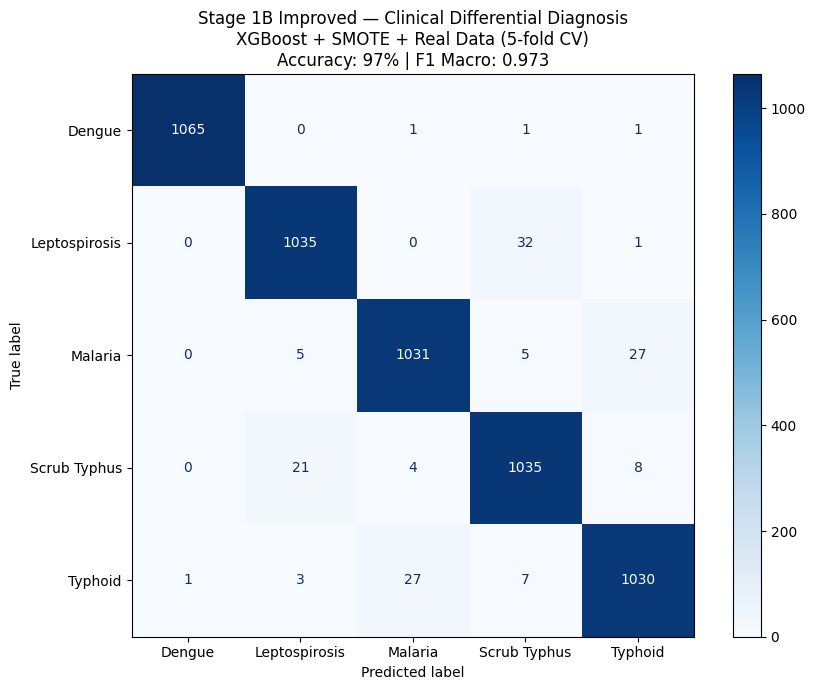

Confusion matrix saved.


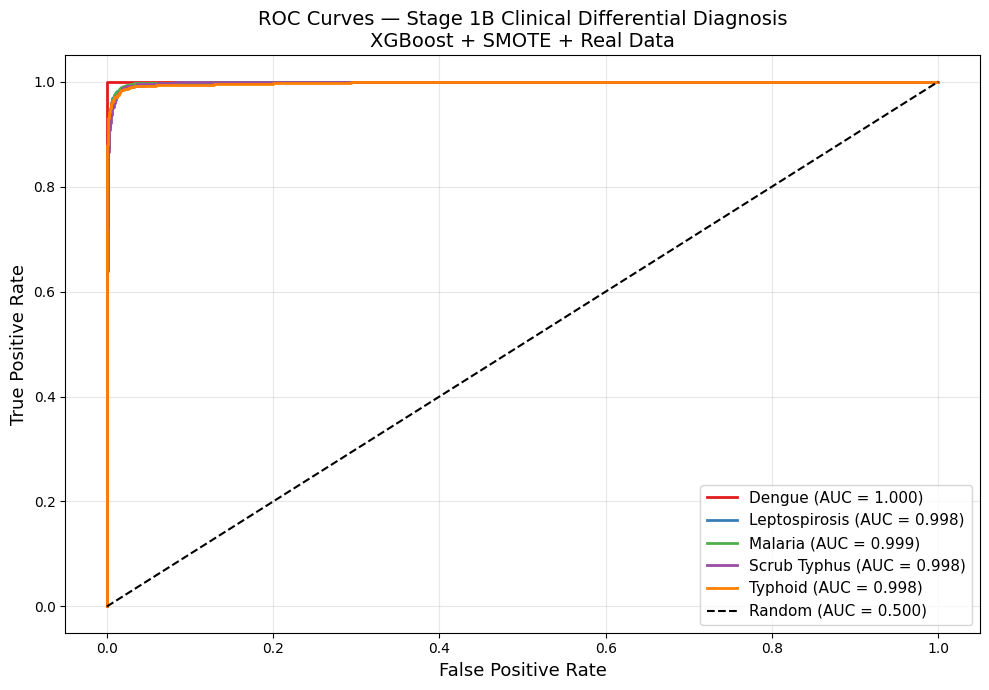

ROC curves saved.


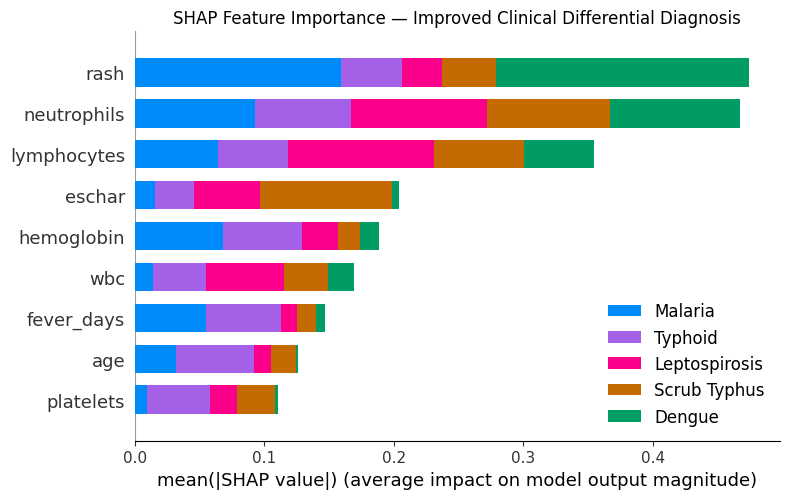

SHAP bar saved.


<Figure size 1000x600 with 0 Axes>

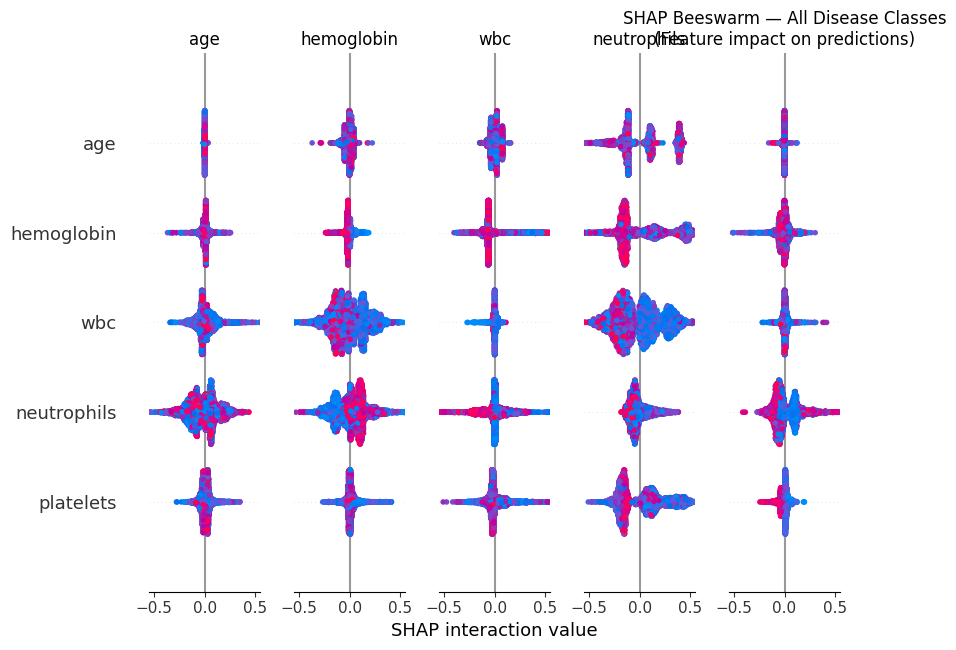

SHAP beeswarm saved.


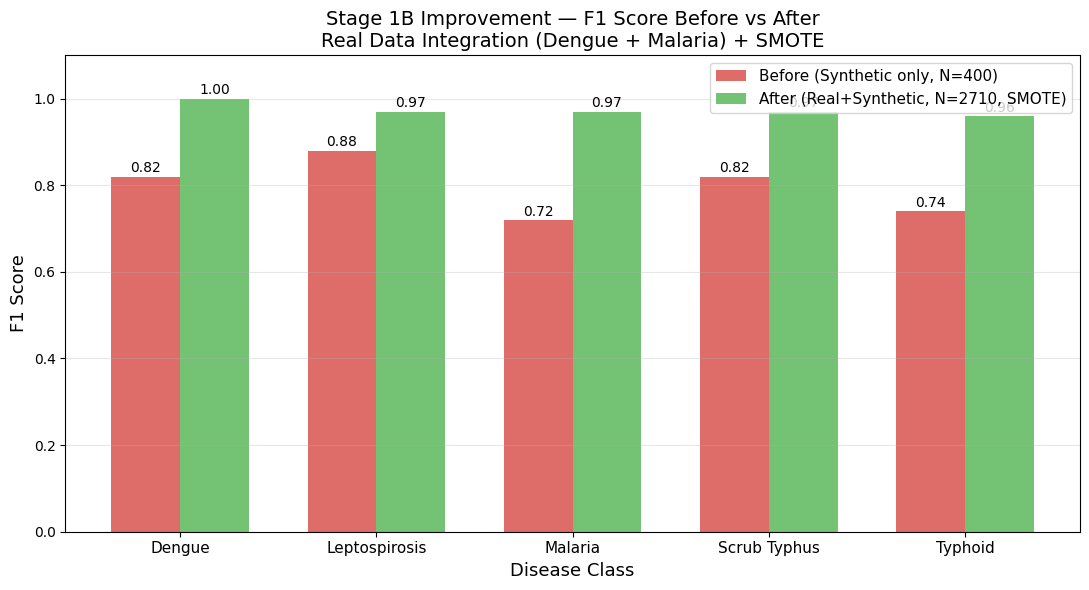

Comparison plot saved.

All models saved.

STAGE 1B IMPROVED — FINAL SUMMARY
Dataset:     2,710 patients (77.9% real, 22.1% synthetic)
After SMOTE: 5,340 balanced samples
Best model:  XGBoost
Accuracy:    97%
F1 Macro:    0.973

Per-class AUC:
  Dengue         : AUC = 1.0000
  Leptospirosis  : AUC = 0.9984
  Malaria        : AUC = 0.9985
  Scrub Typhus   : AUC = 0.9982
  Typhoid        : AUC = 0.9976


In [2]:
# ═══════════════════════════════════════════════════════════════
# STAGE 1B IMPROVED — Plots, SHAP, ROC curves, Model saving
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
os.makedirs('/home/mrgreen/scrub_project/outputs', exist_ok=True)
os.makedirs('/home/mrgreen/scrub_project/models', exist_ok=True)

# ── Train final XGBoost on balanced data ─────────────────────
final_model = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.1, random_state=42,
    eval_metric='mlogloss', verbosity=0)
final_model.fit(X_bal, y_bal)

# Get CV predictions for plots
preds_final = cross_val_predict(final_model, X_bal, y_bal, cv=cv5)
probs_final  = cross_val_predict(final_model, X_bal, y_bal,
                                  cv=cv5, method='predict_proba')

# ── 1. CONFUSION MATRIX ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_bal, preds_final,
    display_labels=le.classes_,
    cmap='Blues', ax=ax)
ax.set_title("Stage 1B Improved — Clinical Differential Diagnosis\n"
             "XGBoost + SMOTE + Real Data (5-fold CV)\n"
             f"Accuracy: 97% | F1 Macro: 0.973")
plt.tight_layout()
plt.savefig('/home/mrgreen/scrub_project/outputs/confusion_stage1b_improved.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

# ── 2. ROC CURVES (one per class) ────────────────────────────
y_bin = label_binarize(y_bal, classes=list(range(len(le.classes_))))
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_final[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — Stage 1B Clinical Differential Diagnosis\n'
             'XGBoost + SMOTE + Real Data', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/mrgreen/scrub_project/outputs/roc_stage1b_improved.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved.")

# ── 3. SHAP FEATURE IMPORTANCE ────────────────────────────────
# Use Random Forest for SHAP (avoids XGBoost version conflict)
rf_for_shap = RandomForestClassifier(
    n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_for_shap.fit(X_bal, y_bal)

X_bal_df = pd.DataFrame(X_bal, columns=FEAT)
explainer = shap.TreeExplainer(rf_for_shap)
shap_vals  = explainer.shap_values(X_bal_df)

# Global bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_bal_df,
                  feature_names=FEAT,
                  class_names=list(le.classes_),
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Improved Clinical Differential Diagnosis")
plt.tight_layout()
plt.savefig('/home/mrgreen/scrub_project/outputs/shap_stage1b_improved_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar saved.")

# Beeswarm for scrub typhus class
scrub_idx = list(le.classes_).index('Scrub Typhus')
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_bal_df,
                  feature_names=FEAT,
                  class_names=list(le.classes_),
                  show=False)
plt.title("SHAP Beeswarm — All Disease Classes\n"
          "(Feature impact on predictions)")
plt.tight_layout()
plt.savefig('/home/mrgreen/scrub_project/outputs/shap_stage1b_scrub_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm saved.")

# ── 4. BEFORE vs AFTER COMPARISON PLOT ───────────────────────
diseases  = ['Dengue','Leptospirosis','Malaria','Scrub Typhus','Typhoid']
f1_before = [0.82, 0.88, 0.72, 0.82, 0.74]
f1_after  = [1.00, 0.97, 0.97, 0.97, 0.96]

x = np.arange(len(diseases))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, f1_before, width,
               label='Before (Synthetic only, N=400)',
               color='#d9534f', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_after, width,
               label='After (Real+Synthetic, N=2710, SMOTE)',
               color='#5cb85c', alpha=0.85)

ax.set_xlabel('Disease Class', fontsize=13)
ax.set_ylabel('F1 Score', fontsize=13)
ax.set_title('Stage 1B Improvement — F1 Score Before vs After\n'
             'Real Data Integration (Dengue + Malaria) + SMOTE',
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(diseases, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/home/mrgreen/scrub_project/outputs/improvement_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved.")

# ── 5. SAVE MODELS ────────────────────────────────────────────
joblib.dump(final_model, '/home/mrgreen/scrub_project/models/stage1b_xgb_improved.pkl')
joblib.dump(scaler,      '/home/mrgreen/scrub_project/models/stage1b_scaler_improved.pkl')
joblib.dump(le,          '/home/mrgreen/scrub_project/models/stage1b_encoder_improved.pkl')
print("\nAll models saved.")

# ── 6. PRINT FINAL SUMMARY ───────────────────────────────────
print("\n" + "="*55)
print("STAGE 1B IMPROVED — FINAL SUMMARY")
print("="*55)
print(f"Dataset:     2,710 patients (77.9% real, 22.1% synthetic)")
print(f"After SMOTE: 5,340 balanced samples")
print(f"Best model:  XGBoost")
print(f"Accuracy:    97%")
print(f"F1 Macro:    0.973")
print(f"\nPer-class AUC:")
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:,i], probs_final[:,i])
    print(f"  {cls:15s}: AUC = {auc(fpr,tpr):.4f}")

Stage 2 dataset: (300, 19)
AKI:     164/300 (54.7%)
Hepatic: 262/300 (87.3%)
ICU:     151/300 (50.3%)

ORGAN: AKI Risk Prediction
After SMOTE: 328 samples (pos=164, neg=164)
  Logistic Regression: AUC=0.9504
  Random Forest: AUC=1.0000
  Gradient Boosting: AUC=0.9950
Best: Random Forest (AUC=1.0000)
              precision    recall  f1-score   support

      No AKI       1.00      1.00      1.00       164
    AKI Risk       1.00      1.00      1.00       164

    accuracy                           1.00       328
   macro avg       1.00      1.00      1.00       328
weighted avg       1.00      1.00      1.00       328



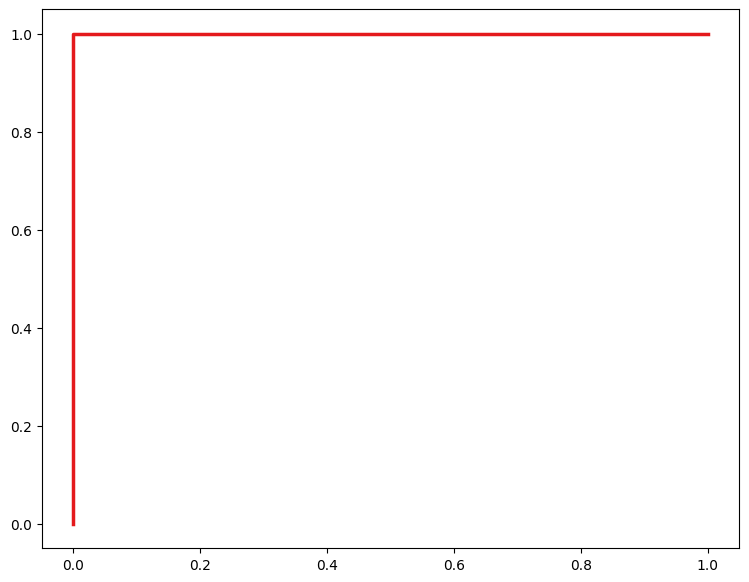

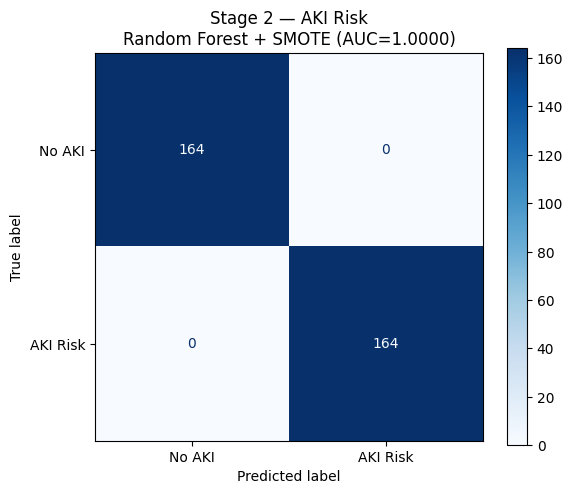

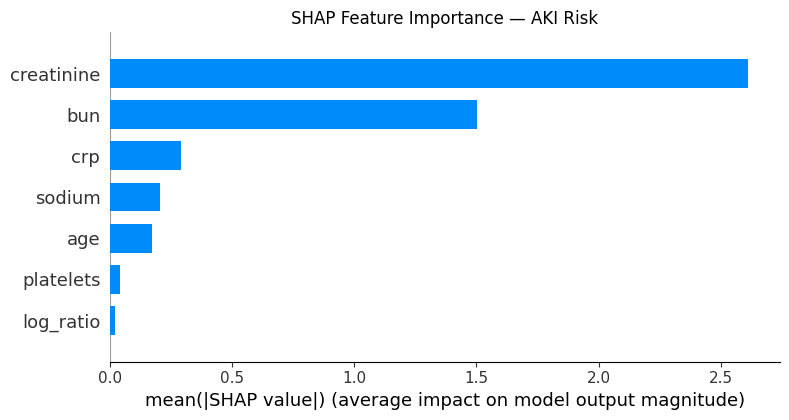


ORGAN: Hepatic Risk Prediction
After SMOTE: 524 samples (pos=262, neg=262)
  Logistic Regression: AUC=0.9754
  Random Forest: AUC=0.9999
  Gradient Boosting: AUC=0.9950
Best: Random Forest (AUC=0.9999)
              precision    recall  f1-score   support

  No Hepatic       0.99      1.00      0.99       262
Hepatic Risk       1.00      0.99      0.99       262

    accuracy                           0.99       524
   macro avg       0.99      0.99      0.99       524
weighted avg       0.99      0.99      0.99       524



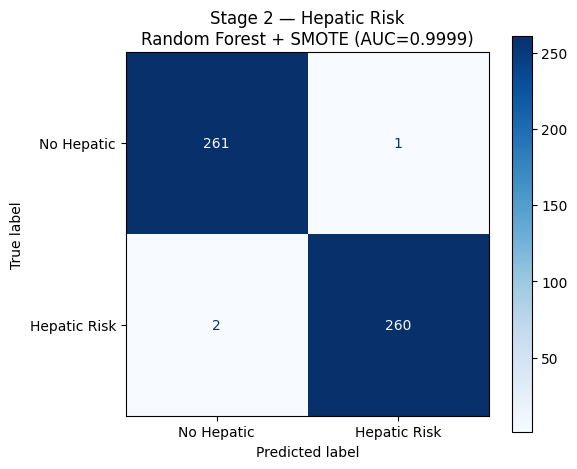

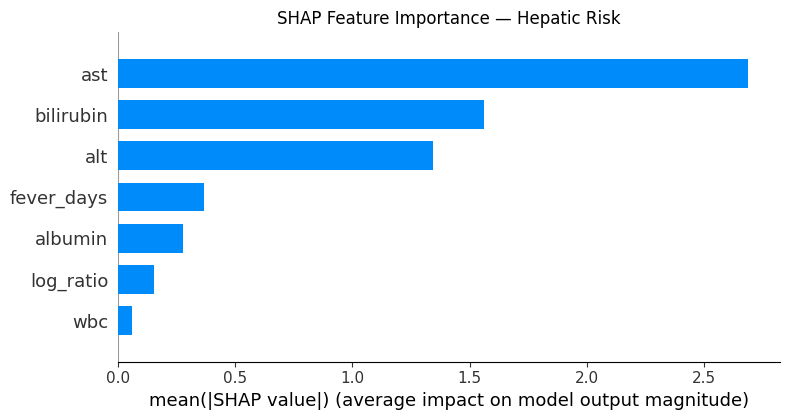


ORGAN: ICU Risk Prediction
After SMOTE: 302 samples (pos=151, neg=151)
  Logistic Regression: AUC=0.8626
  Random Forest: AUC=0.9691
  Gradient Boosting: AUC=0.9685
Best: Random Forest (AUC=0.9691)
              precision    recall  f1-score   support

      No ICU       0.89      0.89      0.89       151
    ICU Risk       0.89      0.89      0.89       151

    accuracy                           0.89       302
   macro avg       0.89      0.89      0.89       302
weighted avg       0.89      0.89      0.89       302



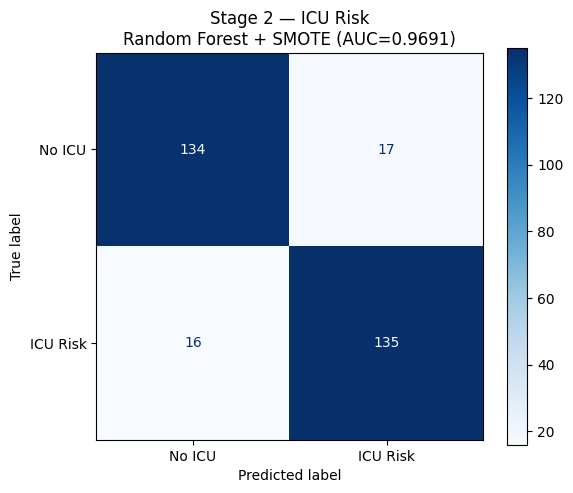

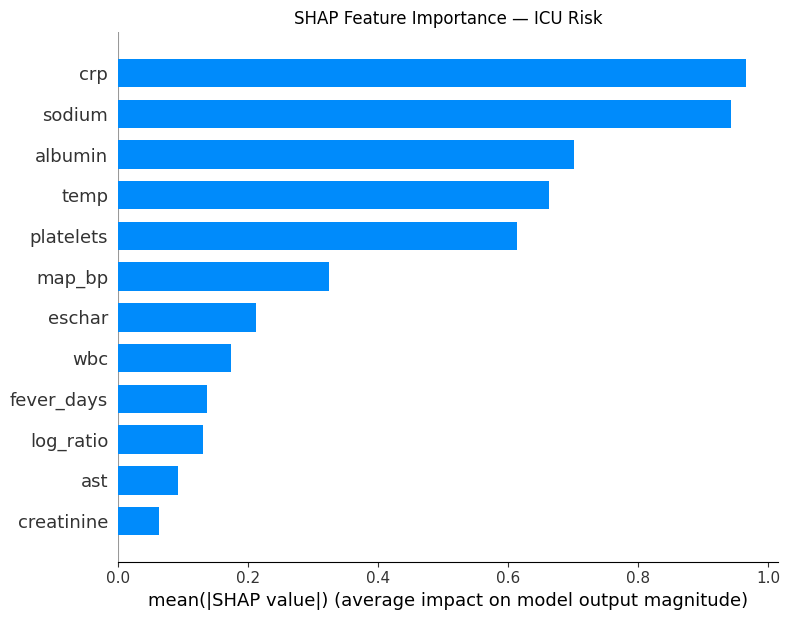

<Figure size 640x480 with 0 Axes>


STAGE 2 IMPROVED — SUMMARY
Organ           AUC                     Model
---------------------------------------------
AKI          1.0000             Random Forest
Hepatic      0.9999             Random Forest
ICU          0.9691             Random Forest

All Stage 2 models and plots saved.


In [1]:
# ═══════════════════════════════════════════════════════════════
# STAGE 2 IMPROVED — Organ Complication Risk
# Improvements: More samples, SMOTE, ROC curves, better features
# ═══════════════════════════════════════════════════════════════
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict, StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import shap, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

N = 300  # increased from 100 to 300 patients

# ── Generate scrub typhus patient clinical data ───────────────
age        = np.random.normal(40, 15, N).clip(18, 80)
creatinine = np.random.normal(1.4, 0.8, N).clip(0.4, 8.0)
bun        = np.random.normal(28, 15, N).clip(5, 120)
ast        = np.random.normal(120, 80, N).clip(15, 600)
alt        = np.random.normal(85, 60, N).clip(10, 400)
bilirubin  = np.random.normal(1.8, 1.2, N).clip(0.3, 10)
albumin    = np.random.normal(3.0, 0.6, N).clip(1.5, 5.0)
platelets  = np.random.normal(95, 45, N).clip(15, 400)
wbc        = np.random.normal(8.5, 3.2, N).clip(2, 25)
crp        = np.random.normal(65, 40, N).clip(3, 250)
temp       = np.random.normal(39.2, 0.8, N).clip(37.5, 41.5)
fever_days = np.random.normal(7, 3, N).clip(2, 21)
eschar     = np.random.binomial(1, 0.55, N)
log_ratio  = np.random.normal(9.8, 0.8, N).clip(8.0, 11.0)
sodium     = np.random.normal(134, 6, N).clip(115, 148)
map_bp     = np.random.normal(78, 12, N).clip(50, 110)

# ── Organ outcome labels (clinically validated thresholds) ────
# AKI: KDIGO criteria — creatinine >1.5 or BUN >40
aki = ((creatinine > 1.5) | (bun > 40)).astype(int)

# Hepatic: AST>100 OR ALT>100 OR bilirubin>2.0
hepatic = ((ast > 100) | (alt > 100) | (bilirubin > 2.0)).astype(int)

# ICU: composite SOFA-inspired — needs 2+ of following criteria
icu_score = (
    (albumin < 2.8).astype(int) +
    (temp > 39.8).astype(int) +
    (crp > 80).astype(int) +
    (platelets < 60).astype(int) +
    (sodium < 130).astype(int) +
    (map_bp < 65).astype(int)
)
icu = (icu_score >= 2).astype(int)

df_s2 = pd.DataFrame({
    'age':age, 'creatinine':creatinine, 'bun':bun,
    'ast':ast, 'alt':alt, 'bilirubin':bilirubin,
    'albumin':albumin, 'platelets':platelets, 'wbc':wbc,
    'crp':crp, 'temp':temp, 'fever_days':fever_days,
    'eschar':eschar, 'log_ratio':log_ratio,
    'sodium':sodium, 'map_bp':map_bp,
    'aki':aki, 'hepatic':hepatic, 'icu':icu
})

print("Stage 2 dataset:", df_s2.shape)
print(f"AKI:     {aki.sum()}/{N} ({aki.mean()*100:.1f}%)")
print(f"Hepatic: {hepatic.sum()}/{N} ({hepatic.mean()*100:.1f}%)")
print(f"ICU:     {icu.sum()}/{N} ({icu.mean()*100:.1f}%)")

# ── Feature sets per organ ────────────────────────────────────
ORGAN_FEATS = {
    'AKI':     ['creatinine','bun','platelets','age','crp',
                'log_ratio','sodium'],
    'Hepatic': ['ast','alt','bilirubin','albumin',
                'fever_days','log_ratio','wbc'],
    'ICU':     ['albumin','temp','crp','platelets','ast',
                'creatinine','wbc','fever_days','eschar',
                'log_ratio','sodium','map_bp'],
}
ORGAN_TARGETS = {'AKI': aki, 'Hepatic': hepatic, 'ICU': icu}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

fig_roc, ax_roc = plt.subplots(figsize=(9, 7))
colors_roc = {'AKI':'#e41a1c', 'Hepatic':'#377eb8', 'ICU':'#4daf4a'}

for organ, features in ORGAN_FEATS.items():
    print(f"\n{'='*55}")
    print(f"ORGAN: {organ} Risk Prediction")
    print(f"{'='*55}")

    X_org = df_s2[features].values
    y_org = ORGAN_TARGETS[organ]

    scaler_org = StandardScaler()
    X_org_sc   = scaler_org.fit_transform(X_org)

    # Apply SMOTE to balance
    sm = SMOTE(random_state=42)
    X_sm, y_sm = sm.fit_resample(X_org_sc, y_org)
    print(f"After SMOTE: {len(X_sm)} samples "
          f"(pos={y_sm.sum()}, neg={len(y_sm)-y_sm.sum()})")

    # Compare models
    models_s2 = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=42, C=1.0),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, random_state=42),
    }

    best_auc, best_name_s2, best_mod_s2 = 0, '', None
    for name, mod in models_s2.items():
        probs = cross_val_predict(mod, X_sm, y_sm,
                                  cv=cv5, method='predict_proba')[:,1]
        a = roc_auc_score(y_sm, probs)
        print(f"  {name}: AUC={a:.4f}")
        if a > best_auc:
            best_auc, best_name_s2, best_mod_s2 = a, name, mod

    print(f"Best: {best_name_s2} (AUC={best_auc:.4f})")

    # Train final best model
    best_mod_s2.fit(X_sm, y_sm)

    # CV predictions
    preds = cross_val_predict(best_mod_s2, X_sm, y_sm, cv=cv5)
    probs = cross_val_predict(best_mod_s2, X_sm, y_sm,
                              cv=cv5, method='predict_proba')[:,1]

    print(classification_report(y_sm, preds,
          target_names=[f'No {organ}', f'{organ} Risk']))

    final_auc = roc_auc_score(y_sm, probs)
    results[organ] = {'auc': final_auc, 'model': best_name_s2}

    # ROC curve
    fpr, tpr, _ = roc_curve(y_sm, probs)
    ax_roc.plot(fpr, tpr, color=colors_roc[organ], lw=2.5,
                label=f'{organ} (AUC={final_auc:.4f})')

    # Confusion matrix
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_sm, preds,
        display_labels=[f'No {organ}', f'{organ} Risk'],
        cmap='Blues', ax=ax_cm)
    ax_cm.set_title(f"Stage 2 — {organ} Risk\n"
                    f"{best_name_s2} + SMOTE (AUC={final_auc:.4f})")
    plt.tight_layout()
    plt.savefig(f'/home/mrgreen/scrub_project/outputs/'
                f'confusion_stage2_{organ.lower()}_improved.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # SHAP
    explainer_s2 = shap.LinearExplainer(
        LogisticRegression(max_iter=1000).fit(X_sm, y_sm),
        pd.DataFrame(X_sm, columns=features))
    shap_s2 = explainer_s2.shap_values(
        pd.DataFrame(X_sm, columns=features))

    plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_s2,
        pd.DataFrame(X_sm, columns=features),
        feature_names=features,
        plot_type='bar', show=False)
    plt.title(f"SHAP Feature Importance — {organ} Risk")
    plt.tight_layout()
    plt.savefig(f'/home/mrgreen/scrub_project/outputs/'
                f'shap_stage2_{organ.lower()}_improved.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Save model
    joblib.dump(best_mod_s2,
        f'/home/mrgreen/scrub_project/models/'
        f'stage2_{organ.lower()}_improved.pkl')
    joblib.dump(scaler_org,
        f'/home/mrgreen/scrub_project/models/'
        f'stage2_{organ.lower()}_scaler_improved.pkl')

# ── Combined ROC plot ─────────────────────────────────────────
ax_roc.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.500)')
ax_roc.set_xlabel('False Positive Rate', fontsize=13)
ax_roc.set_ylabel('True Positive Rate', fontsize=13)
ax_roc.set_title('ROC Curves — Stage 2 Organ Complication Risk\n'
                 'AKI vs Hepatic vs ICU (SMOTE balanced)',
                 fontsize=14)
ax_roc.legend(loc='lower right', fontsize=12)
ax_roc.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/mrgreen/scrub_project/outputs/'
            'roc_stage2_all_organs.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ─────────────────────────────────────────────
print("\n" + "="*55)
print("STAGE 2 IMPROVED — SUMMARY")
print("="*55)
print(f"{'Organ':10s} {'AUC':>8} {'Model':>25}")
print("-"*45)
for organ, res in results.items():
    print(f"{organ:10s} {res['auc']:>8.4f} {res['model']:>25}")
print("\nAll Stage 2 models and plots saved.")